The moving average process of order $q$ is denoted MA$(q)$ and defined by

$$y_t = w_t+\theta_1w_{t-1}+...+\theta_qw_{t-q},$$
which can be rewritten as 

$$y_t = \sum_{j=0}^q\theta_jw_{t-j},$$

where $\theta_0 =1$, $\theta_1, \theta_2, ..., \theta_q$ are fixed constants, and  $w_t$ denotes a random variable with mean $0$ and variance $\sigma^2$. In the MA model the current value of the series is a weighted sum of past white noise terms. Think of the white noise series as being stochastically uncorrelated information which appears at each time step, and which is combined with other information to provide the observation at $y_t$. Hence, moving average models are useful for modeling series that are affected by a variety of unpredictable events where the effect of these events have an immediate effect as well as possible long-term effects.

The moving average process is a stationary process with serial correlation zero at lags greater than $q$. 

$$
\gamma(k) = 
\begin{cases}
0,  & \vert k\vert > q \\
\sigma^2\sum_{j=0}^{q-\vert k\vert}\theta_j\theta_{j+k} & \vert k\vert \le q
\end{cases}
$$

We already got to know Python's [`DataFrame.rolling()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) function to calculate moving average series. 

In [1]:
%load_ext lab_black

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

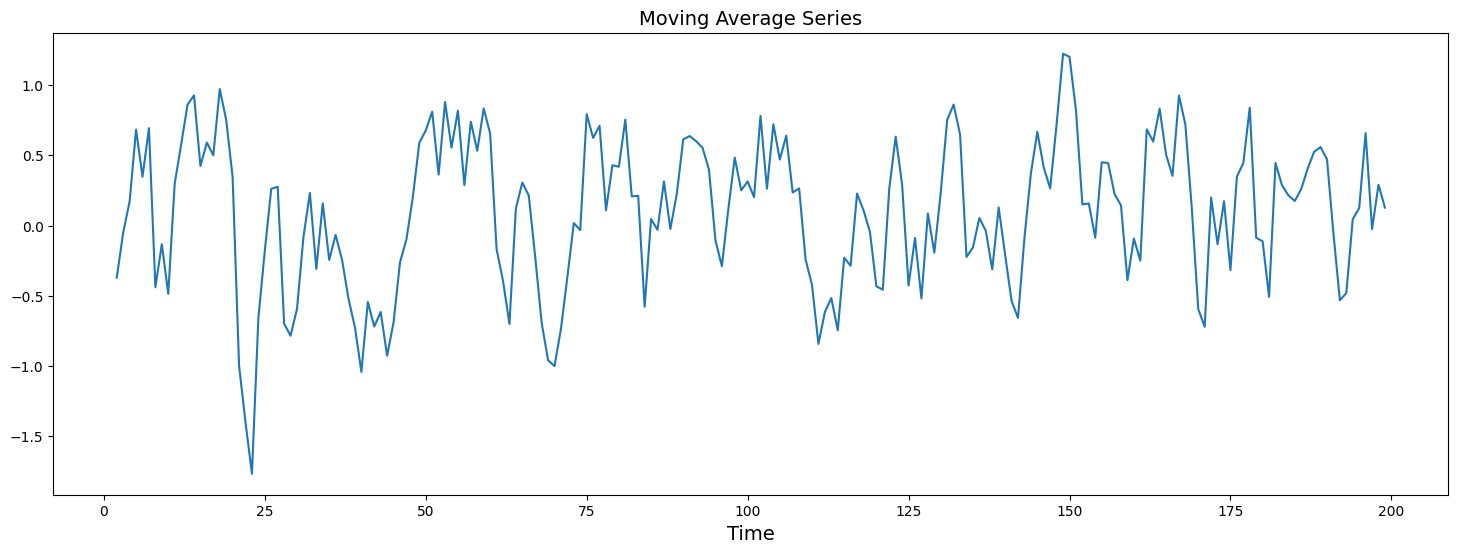

In [3]:
# seed random number generator
random.seed(250)


# create white noise series
mean = 0
std = 1
n = 200
w = np.random.normal(mean, std, size=n)

## moving average

w_series = pd.Series(w)  # Convert array of integers to pandas series

window_size = 3
windows = w_series.rolling(window_size)

moving_averages = windows.mean()  # Create a series of moving averages of each window


## plot
plt.figure(figsize=(18, 6))
plt.plot(moving_averages)
plt.title("Moving Average Series", fontsize=14)
plt.xlabel("Time", fontsize=14)
plt.show()

Another, very convenient way to simulate moving average processes in Python is to use the class [`statsmodels.tsa.arima.model.ARIMA`](https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima.model.ARIMA.html).

Where ARIMA stands for:
- autoregressive models: AR(p), p denotes the order. It is also called lag order, because it denotes the number of lag observations included in the model
- moving average models: MA(q), where q denotes the order of of moving average. It is the size of the moving average window.
- mixed autoregressive moving average models: ARMA(p, q)
- integration models: ARIMA(p, d, q), where p and q are as above and d is the degree of differencing, i.e. the number of times that the raw observations are differenced.


We start by using [`statsmodels.tsa.arima_process.ArmaProcess`](https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima_process.ArmaProcess.html), which can handle AR and MA models. 


We start with generating two MA(1) series (MA model of order $q=1$):

$$y_t = w_t+\theta_1w_{t-1}\text{,}$$

where we consider once $\theta_1 = 0.6$ and the other time $\theta_1 = -0.6$. 
We store the weights in `ma1`. Finally, we simulate the process by generating a 100 data points:

In [4]:
from statsmodels.tsa.arima_process import ArmaProcess


# MA parameter: 0.6
ar1 = np.array([1])  # we must include the zero-lag coefficient of 1
ma1 = np.array([1, +0.6])
MA_object1 = ArmaProcess(ar1, ma1)
simulated_ma1_1 = MA_object1.generate_sample(nsample=100)


# MA parameter: -0.6
ar2 = np.array([1])
ma2 = np.array([1, -0.6])
MA_object2 = ArmaProcess(ar2, ma2)
simulated_ma1_2 = MA_object2.generate_sample(nsample=100)

We plot the two series:


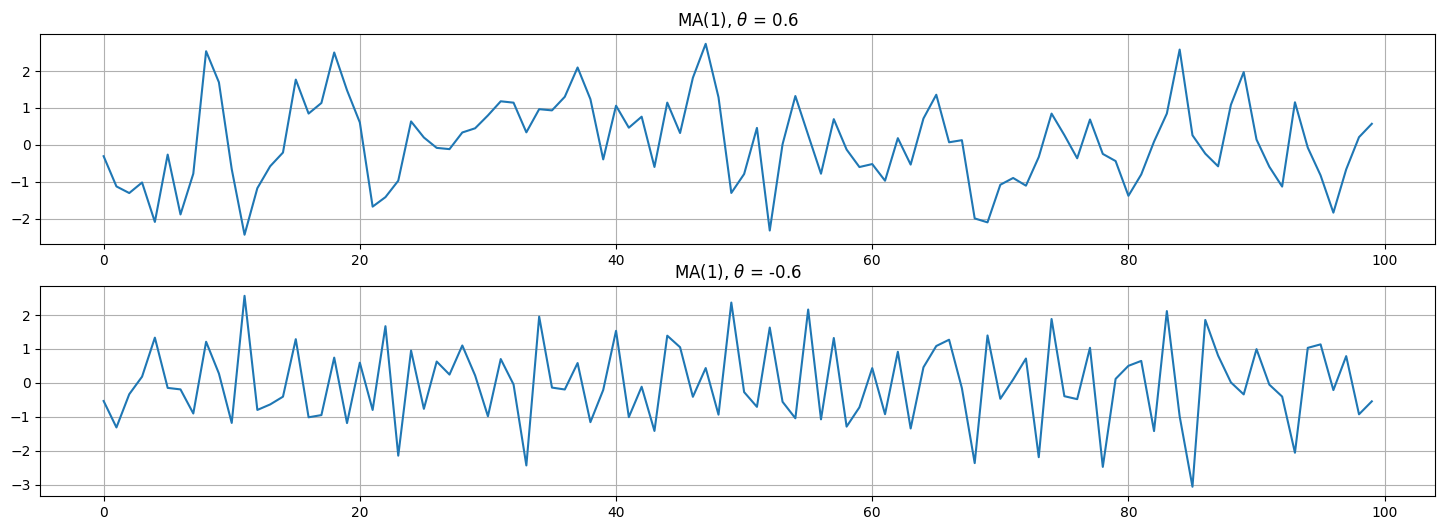

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(18, 6))
ax[0].plot(simulated_ma1_1)
ax[0].set_title("MA(1), $\\theta$ = 0.6")


ax[1].plot(simulated_ma1_2)
ax[1].set_title("MA(1), $\\theta$ = -0.6")

ax[0].grid()
ax[1].grid()
plt.show()


For $\theta = 0.6$, $y_t$  and $y_{t-1}$ are positively correlated, and for $\theta = -0.6$, $y_t$  and $y_{t-1}$ are negatively correlated. This correlational structure  can be shown by plotting the correlogram. 


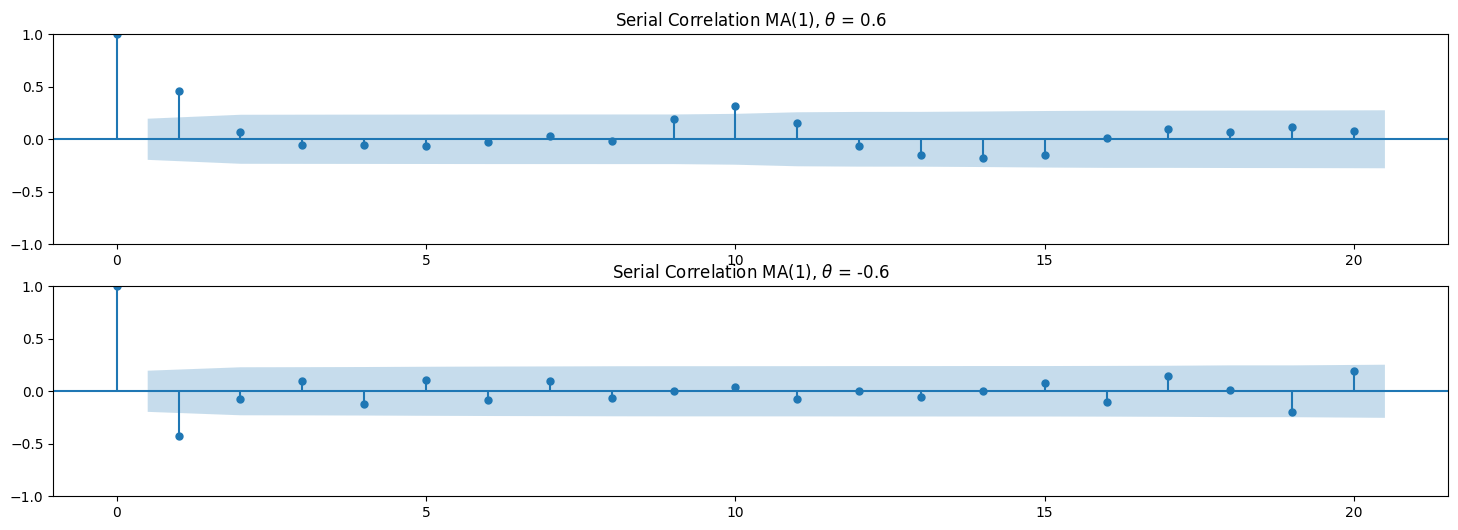

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2, 1, figsize=(18, 6))

plot_acf(simulated_ma1_1, ax=ax[0])
ax[0].set_title("Serial Correlation MA(1), $\\theta$ = 0.6")

plot_acf(simulated_ma1_2, ax=ax[1])
ax[1].set_title("Serial Correlation MA(1), $\\theta$ = -0.6")

plt.show()



A typical feature of the autocorrelation function of a MA process is that it drops to nearly zero beyond $q$.





In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))